In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_json("../data/sentinel_1425.jsonl", lines=True)

df.shape

(1425, 9)

In [2]:
df.head()

,sample,temperature,humidity,gas_raw,presence,delta_temp,delta_humidity,delta_gas,presence_change
0,1,37.55,35.46,2308,False,0.00,0.00,0,0
1,2,37.02,35.58,2421,True,-0.53,0.12,113,1
2,3,36.15,36.37,2451,True,-0.87,0.79,30,0
3,4,35.60,37.18,2687,True,-0.55,0.80,236,0
4,5,34.65,38.29,2696,True,-0.95,1.11,9,0


In [3]:
# Identifier les débuts des différentes séquences

debut_sequence = (
    ~np.isclose(
        df["temperature"].diff().fillna(0),
        df["delta_temp"],
        atol=0.02
    )
    |
    ~np.isclose(
        df["humidity"].diff().fillna(0),
        df["delta_humidity"],
        atol=0.02
    )
    |
    (
        df["gas_raw"].diff().fillna(0)
        != df["delta_gas"]
    )
)

# La première observation commence une séquence
debut_sequence = pd.Series(debut_sequence, index=df.index)
debut_sequence.iloc[0] = True

# Identifier les différentes séquences
df["groupe_sequence"] = debut_sequence.cumsum()


# Recalculer les variations sur 5 observations

df["variation_temp_5"] = (
    df["temperature"]
    - df.groupby("groupe_sequence")["temperature"].shift(5)
)

df["variation_gas_5"] = (
    df["gas_raw"]
    - df.groupby("groupe_sequence")["gas_raw"].shift(5)
)


# Vérification
print("Nombre de séquences détectées :", df["groupe_sequence"].nunique())

df[[
    "sample",
    "temperature",
    "gas_raw",
    "variation_temp_5",
    "variation_gas_5"
]].head(10)

Nombre de séquences détectées : 18


,sample,temperature,gas_raw,variation_temp_5,variation_gas_5
0,1,37.55,2308,NaN,NaN
1,2,37.02,2421,NaN,NaN
2,3,36.15,2451,NaN,NaN
3,4,35.60,2687,NaN,NaN
4,5,34.65,2696,NaN,NaN
5,6,33.72,2453,-3.83,145.0
6,7,32.77,2275,-4.25,-146.0
7,8,32.31,2259,-3.84,-192.0
8,9,31.51,2371,-4.09,-316.0
9,10,31.31,2384,-3.34,-312.0


In [4]:
# 1. Identifier les anomalies critiques

temp_critique = df["temperature"] >= 40
gaz_critique = df["gas_raw"] >= 3000
intrusion = df["presence"] == True


# 2. Compter les anomalies critiques simultanées

nb_anomalies = (
    temp_critique.astype(int)
    + gaz_critique.astype(int)
    + intrusion.astype(int)
)


# 3. Identifier les situations de pré-alerte

pre_alerte = (
    ((df["temperature"] >= 35) & (df["temperature"] < 40))
    |
    ((df["gas_raw"] >= 2500) & (df["gas_raw"] < 3000))
    |
    (df["variation_temp_5"] >= 3.5)
    |
    (df["variation_gas_5"] >= 700)
)


# 4. Définir les conditions par priorité

conditions = [
    nb_anomalies >= 2,
    temp_critique,
    gaz_critique,
    intrusion,
    pre_alerte
]


# 5. Associer chaque condition à une classe

classes = [
    "INCIDENT_COMBINE",
    "SURCHAUFFE",
    "FUITE_GAZ",
    "INTRUSION",
    "PRE_ALERTE"
]


# 6. Créer la colonne cible

df["classe"] = np.select(
    conditions,
    classes,
    default="NORMAL"
)


# 7. Vérifier la répartition

df["classe"].value_counts()

classe
NORMAL              290
PRE_ALERTE          286
FUITE_GAZ           233
SURCHAUFFE          214
INTRUSION           202
INCIDENT_COMBINE    200
Name: count, dtype: int64

## 🔍 Vérification des données avant l'entraînement

Avant de préparer les variables du modèle Random Forest, nous vérifions les séquences d'observations ainsi que les valeurs manquantes générées par le calcul des variables temporelles.

In [5]:
# Nombre de séquences identifiées
print("Nombre de séquences :", df["groupe_sequence"].nunique())

# Valeurs manquantes dans les variables temporelles
print("\nValeurs manquantes :")

print(df[[
    "variation_temp_5",
    "variation_gas_5"
]].isnull().sum())

Nombre de séquences : 18

Valeurs manquantes :
variation_temp_5    90
variation_gas_5     90
dtype: int64


### ✅ Traitement des valeurs manquantes

Le dataset contient 18 séquences de simulation indépendantes.

Le calcul des variations sur cinq observations produit
90 valeurs manquantes pour chaque variable temporelle,
correspondant aux cinq premières observations de chaque séquence.

Ces observations sont exclues du dataset destiné à
l'entraînement afin de conserver uniquement les mesures
disposant d'un historique temporel suffisant.

In [6]:
# Créer une copie destinée au Machine Learning
# en supprimant les lignes sans historique temporel suffisant

df_ml = df.dropna(
    subset=["variation_temp_5", "variation_gas_5"]
).copy()

# Vérifier les dimensions du nouveau dataset
print("Dataset initial :", df.shape)
print("Dataset pour Random Forest :", df_ml.shape)

# Vérifier la répartition des classes
print("\nRépartition des classes :")
print(df_ml["classe"].value_counts())

Dataset initial : (1425, 13)
Dataset pour Random Forest : (1335, 13)

Répartition des classes :
classe
PRE_ALERTE          262
FUITE_GAZ           233
NORMAL              228
SURCHAUFFE          214
INCIDENT_COMBINE    200
INTRUSION           198
Name: count, dtype: int64


## 🌳 Préparation des variables X et y

Pour entraîner le modèle Random Forest, nous séparons les données en deux parties :

- **X (variables explicatives)** : les mesures des détecteurs et les variables temporelles.
- **y (variable cible)** : la classe du scénario à prédire.

La colonne `sample` est exclue car elle représente uniquement le numéro de l'observation.

L'identifiant `groupe_sequence` est également exclu des variables explicatives. Il sera conservé séparément pour organiser la séparation entre entraînement et test.

In [7]:
# Définition des variables explicatives
variables = [
    "temperature",
    "humidity",
    "gas_raw",
    "presence",
    "delta_temp",
    "delta_humidity",
    "delta_gas",
    "presence_change",
    "variation_temp_5",
    "variation_gas_5"
]

# Variables explicatives
X = df_ml[variables]

# Variable cible
y = df_ml["classe"]

# Vérification
print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Dimensions de X : (1335, 10)
Dimensions de y : (1335,)


## 🌳 Séparation des données d'entraînement et de test

Afin d'évaluer le modèle Random Forest, nous allons séparer
les observations en deux ensembles : entraînement et test.

La séparation tiendra compte des différentes séquences de
simulation afin d'éviter que des observations provenant
d'une même séquence soient utilisées à la fois pour
l'entraînement et pour l'évaluation.

Nous vérifions d'abord la répartition des classes
dans chaque séquence.

In [9]:
# Répartition des classes par séquence
repartition_sequences = pd.crosstab(
    df_ml["groupe_sequence"],
    df_ml["classe"]
)

repartition_sequences

classe,FUITE_GAZ,INCIDENT_COMBINE,INTRUSION,NORMAL,PRE_ALERTE,SURCHAUFFE
groupe_sequence,,,,,,
1,15,13,198,186,81,2
2,0,0,0,2,10,38
3,3,35,0,0,10,0
4,37,0,0,0,9,0
5,42,0,0,1,12,0
6,0,0,0,2,13,30
7,35,0,0,4,9,0
8,0,19,0,1,10,18
9,0,0,0,3,14,36


## 🏷️ Révision des classes de scénarios

La variable `presence` a été exclue de la classification,
car le détecteur PIR ne permet pas de distinguer une
présence autorisée d'une véritable intrusion.

Le modèle Random Forest se concentrera donc sur les
anomalies de température et de gaz.

Les cinq classes retenues sont :

- NORMAL
- PRE_ALERTE
- SURCHAUFFE
- FUITE_GAZ
- INCIDENT_COMBINE

La classe INCIDENT_COMBINE correspond désormais à une
température et un niveau de gaz critiques simultanément.

In [10]:
# Identification des anomalies critiques
temp_critique = df_ml["temperature"] >= 40
gaz_critique = df_ml["gas_raw"] >= 3000

# Identification des pré-alertes
pre_alerte = (
    (df_ml["temperature"] >= 35)
    |
    (df_ml["gas_raw"] >= 2500)
    |
    (df_ml["variation_temp_5"] >= 3.5)
    |
    (df_ml["variation_gas_5"] >= 700)
)

# Réétiquetage avec cinq classes
df_ml["classe"] = np.select(
    [
        temp_critique & gaz_critique,
        temp_critique,
        gaz_critique,
        pre_alerte
    ],
    [
        "INCIDENT_COMBINE",
        "SURCHAUFFE",
        "FUITE_GAZ",
        "PRE_ALERTE"
    ],
    default="NORMAL"
)

# Nouvelle répartition des classes
df_ml["classe"].value_counts()

classe
NORMAL              362
PRE_ALERTE          326
FUITE_GAZ           282
SURCHAUFFE          263
INCIDENT_COMBINE    102
Name: count, dtype: int64

### ✅ Observation

Après l'exclusion du scénario INTRUSION, le dataset contient
désormais cinq classes basées uniquement sur la température,
le niveau de gaz et leurs variations temporelles.

Les classes NORMAL, PRE_ALERTE, FUITE_GAZ et SURCHAUFFE
présentent une répartition relativement homogène.

La classe INCIDENT_COMBINE reste moins représentée,
avec 102 observations sur les 1 335 disponibles.

Cette répartition sera prise en compte lors de
l'entraînement et de l'évaluation du modèle Random Forest.

In [11]:
# Variables explicatives retenues
variables = [
    "temperature",
    "humidity",
    "gas_raw",
    "delta_temp",
    "delta_humidity",
    "delta_gas",
    "variation_temp_5",
    "variation_gas_5"
]

# Nouvelles variables explicatives
X = df_ml[variables].copy()

# Nouvelle variable cible : 5 classes
y = df_ml["classe"].copy()

# Identifiants des séquences
groupes = df_ml["groupe_sequence"]

# Vérification
print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)
print("Nombre de classes :", y.nunique())

Dimensions de X : (1335, 8)
Dimensions de y : (1335,)
Nombre de classes : 5


In [12]:
from sklearn.model_selection import GroupShuffleSplit

# Séparation par groupe de séquences
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groupes)
)

# Création des ensembles
X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# Vérification des dimensions
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("\nClasses dans Train :")
print(y_train.value_counts())

print("\nClasses dans Test :")
print(y_test.value_counts())

X_train : (692, 8)
X_test  : (643, 8)

Classes dans Train :
classe
FUITE_GAZ           264
SURCHAUFFE          148
PRE_ALERTE          144
INCIDENT_COMBINE    101
NORMAL               35
Name: count, dtype: int64

Classes dans Test :
classe
NORMAL              327
PRE_ALERTE          182
SURCHAUFFE          115
FUITE_GAZ            18
INCIDENT_COMBINE      1
Name: count, dtype: int64


In [13]:
# Répartition des cinq classes par séquence

repartition_sequences = pd.crosstab(
    df_ml["groupe_sequence"],
    df_ml["classe"]
)

repartition_sequences

classe,FUITE_GAZ,INCIDENT_COMBINE,NORMAL,PRE_ALERTE,SURCHAUFFE
groupe_sequence,,,,,
1,18,1,320,145,11
2,0,0,2,10,38
3,3,35,0,10,0
4,37,0,0,9,0
5,42,0,1,12,0
6,0,0,2,13,30
7,35,0,4,9,0
8,0,0,1,10,37
9,0,0,3,14,36


### 📊 Ajustement de la séparation Train / Test

Une première séparation aléatoire par séquences a révélé
un déséquilibre important entre les ensembles d'entraînement
et de test.

Nous retenons donc une séparation par groupes adaptée à
la distribution de nos cinq classes.

L'objectif est de conserver des séquences indépendantes
dans chaque ensemble et de disposer d'exemples des cinq
scénarios lors de l'évaluation.

In [14]:
# Séquences réservées pour le test
groupes_test = [5, 8, 9, 12, 13, 17]

# Identifier les observations appartenant au test
masque_test = df_ml["groupe_sequence"].isin(groupes_test)

# Création des ensembles d'entraînement
X_train = X.loc[~masque_test].copy()
y_train = y.loc[~masque_test].copy()

# Création des ensembles de test
X_test = X.loc[masque_test].copy()
y_test = y.loc[masque_test].copy()

# Vérification des dimensions
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

# Répartition des classes
print("\nClasses dans Train :")
print(y_train.value_counts())

print("\nClasses dans Test :")
print(y_test.value_counts())

X_train : (1030, 8)
X_test  : (305, 8)

Classes dans Train :
classe
NORMAL              341
PRE_ALERTE          258
FUITE_GAZ           206
SURCHAUFFE          157
INCIDENT_COMBINE     68
Name: count, dtype: int64

Classes dans Test :
classe
SURCHAUFFE          106
FUITE_GAZ            76
PRE_ALERTE           68
INCIDENT_COMBINE     34
NORMAL               21
Name: count, dtype: int64


## 🌳 Entraînement du modèle Random Forest

Nous utilisons l'algorithme Random Forest pour apprendre
à classifier les observations selon les cinq scénarios définis.

Le modèle est entraîné à partir des huit variables explicatives
sélectionnées précédemment.

L'entraînement est effectué sur les 1 030 observations
de l'ensemble Train, tandis que les 305 observations
de l'ensemble Test sont réservées à l'évaluation.

In [15]:
from sklearn.ensemble import RandomForestClassifier

# Initialisation du modèle Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# Entraînement du modèle
rf_model.fit(X_train, y_train)

print("✅ Entraînement du modèle Random Forest terminé !")

✅ Entraînement du modèle Random Forest terminé !


## 🔍 Prédictions sur l'ensemble de test

Après l'entraînement, nous utilisons le modèle Random Forest
pour prédire les classes des observations de l'ensemble Test.

Les classes prédites seront comparées aux classes réelles
(étiquettes de référence) afin d'évaluer les performances du modèle.

In [17]:
# Prédire les classes de l'ensemble Test
y_pred = rf_model.predict(X_test)

# Comparer les classes réelles et prédites
resultats = pd.DataFrame({
    "Classe réelle": y_test.values,
    "Classe prédite": y_pred
})

# Afficher les 10 premières prédictions
resultats.head(10)

,Classe réelle,Classe prédite
0,PRE_ALERTE,NORMAL
1,NORMAL,NORMAL
2,PRE_ALERTE,PRE_ALERTE
3,PRE_ALERTE,PRE_ALERTE
4,PRE_ALERTE,PRE_ALERTE
5,PRE_ALERTE,PRE_ALERTE
6,PRE_ALERTE,PRE_ALERTE
7,PRE_ALERTE,PRE_ALERTE
8,PRE_ALERTE,PRE_ALERTE
9,PRE_ALERTE,PRE_ALERTE


## 📊 Évaluation des performances du modèle

### 🎯 Accuracy

L'accuracy représente la proportion d'observations correctement
classifiées par le modèle sur l'ensemble de test.

Elle permet d'obtenir une première mesure globale des
performances de Random Forest.

In [18]:
from sklearn.metrics import accuracy_score

# Calcul de l'accuracy
accuracy = accuracy_score(y_test, y_pred)

# Affichage du résultat
print(f"Accuracy du modèle Random Forest : {accuracy:.2%}")

Accuracy du modèle Random Forest : 99.67%


===== RANDOM FOREST =====

Accuracy : 99.67%

===== RAPPORT DE CLASSIFICATION =====

                  precision    recall  f1-score   support

       FUITE_GAZ      1.000     1.000     1.000        76
INCIDENT_COMBINE      1.000     1.000     1.000        34
          NORMAL      0.955     1.000     0.977        21
      PRE_ALERTE      1.000     0.985     0.993        68
      SURCHAUFFE      1.000     1.000     1.000       106

        accuracy                          0.997       305
       macro avg      0.991     0.997     0.994       305
    weighted avg      0.997     0.997     0.997       305



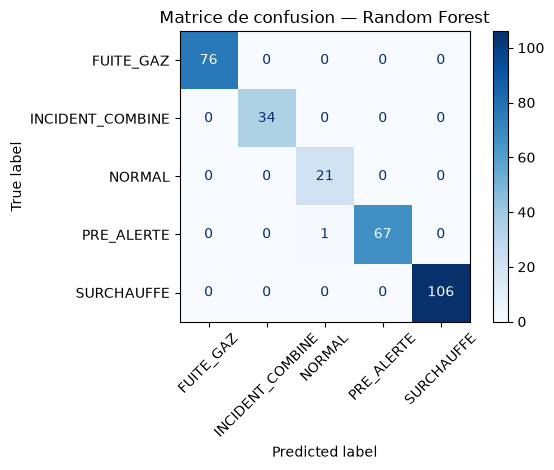

In [19]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

# 1. Accuracy
print("===== RANDOM FOREST =====")

print(f"\nAccuracy : {accuracy_score(y_test, y_pred):.2%}")

# 2. Rapport de classification
print("\n===== RAPPORT DE CLASSIFICATION =====\n")

print(classification_report(y_test, y_pred, digits=3))

# 3. Matrice de confusion
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=rf_model.classes_,
    cmap="Blues",
    values_format="d",
    xticks_rotation=45
)

plt.title("Matrice de confusion — Random Forest")
plt.tight_layout()
plt.show()

### ✅ Analyse des résultats

Le modèle Random Forest atteint une **accuracy de 99,67 %**
sur les 305 observations de l'ensemble de test.

Le rapport de classification montre d'excellentes performances
sur les cinq scénarios, avec des F1-scores compris entre
**97,7 % et 100 %**.

La matrice de confusion révèle une seule erreur :
une observation **PRE_ALERTE** a été classifiée comme **NORMAL**.

Les scénarios critiques **SURCHAUFFE**, **FUITE_GAZ** et
**INCIDENT_COMBINE** ont été correctement identifiés dans
l'ensemble de test.

Ces résultats montrent que Random Forest reproduit
efficacement les règles de classification définies
pour nos scénarios simulés.

In [20]:
import joblib

# Sauvegarder le modèle Random Forest
joblib.dump(
    {
        "modele": rf_model,
        "variables": X_train.columns.tolist()
    },
    "../random_forest_sentinel.joblib"
)

print("✅ Modèle Random Forest sauvegardé !")

✅ Modèle Random Forest sauvegardé !
